In [1]:
#ensemble learning (voting classifier)
import pandas as pd
import numpy as np
import joblib
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,
    confusion_matrix,classification_report,ConfusionMatrixDisplay,roc_curve)
import matplotlib.pyplot as plt

In [2]:
train_df = pd.read_csv("../data/processed/train_smote.csv")
test_df = pd.read_csv("../data/processed/test_data.csv")
print(train_df.shape)
print(test_df.shape)

(1582354, 48)
(200000, 48)


In [3]:
X_train = train_df.drop("fraud_bool", axis=1)
y_train = train_df["fraud_bool"]
X_test = test_df.drop("fraud_bool", axis=1)
y_test = test_df["fraud_bool"]

In [4]:
#defining base models 
lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(n_estimators=200,random_state=42,n_jobs=-1)
xgb = XGBClassifier(n_estimators=200,learning_rate=0.1,max_depth=6,eval_metric="logloss",random_state=42)

In [5]:
#creating voting classifire
ensemble = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('dt', dt),
        ('rf', rf),
        ('xgb', xgb)
    ],
    voting='soft'
)

In [7]:
#Train Ensemble Model
ensemble.fit(X_train, y_train)

c:\Users\dell\OneDrive\Desktop\Financial-Fraud-Detection\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('dt', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[LogisticRegre...max_iter=1000), DecisionTreeC...ndom_state=42), RandomForestC...ndom_state=42), XGBClassifier...ree=None, ...)]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[<U32](47,)","['income','name_email_similarity','prev_address_months_count',..., 'device_os_2','device_os_3','device_os_4']"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()


In [8]:
#Predictions
y_pred = ensemble.predict(X_test)
y_prob = ensemble.predict_proba(X_test)[:,1]

In [9]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.98099
Precision: 0.13891402714932127
Recall   : 0.13916591115140525
F1 Score : 0.13903985507246377
ROC AUC  : 0.8022380831560324


In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99    197794
           1       0.14      0.14      0.14      2206

    accuracy                           0.98    200000
   macro avg       0.56      0.56      0.56    200000
weighted avg       0.98      0.98      0.98    200000



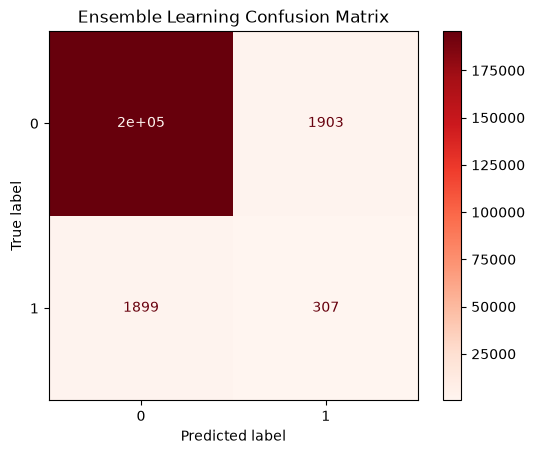

In [11]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Reds")
plt.title("Ensemble Learning Confusion Matrix")
plt.show()

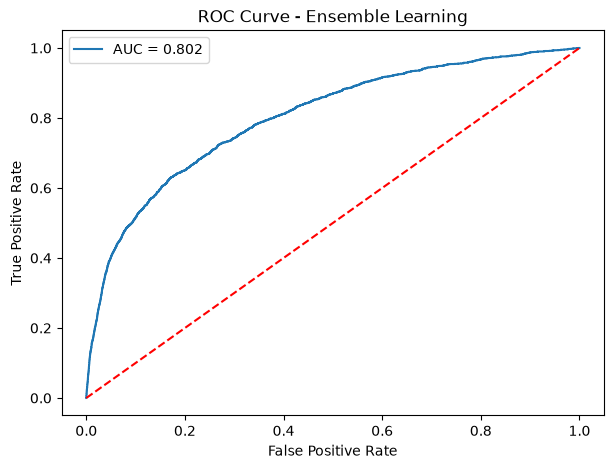

In [12]:
fpr, tpr, threshold = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr,
         label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Ensemble Learning")
plt.legend()
plt.show()

In [13]:
joblib.dump(ensemble,"../models/ensemble_model.pkl")
print("Ensemble model saved successfully.")

Ensemble model saved successfully.


## Summary

• Loaded SMOTE-balanced training data and original test dataset.
• Built an Ensemble Learning model using Voting Classifier.
• Combined Logistic Regression, Decision Tree, Random Forest, and XGBoost.
• Used soft voting to aggregate prediction probabilities.
• Evaluated performance using Accuracy, Precision, Recall, F1-score, and ROC-AUC.
• Generated Classification Report, Confusion Matrix, and ROC Curve.
• Saved the trained ensemble model for future deployment.